### Final ECE 143 Project Notebook

In [1]:
# Setup block, run first every time!

# --- IMPORTS ---
import pandas as pd
import numpy as np
import json
import gc
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.stats import pointbiserialr
import seaborn as sns
import os

from scripts.reviews_over_time import plot_reviews_over_time
from scripts.stats_tests import run_tests


# --- INITIALIZATIONS & PATHS ---
BASE_PATH = r"G:\AmazonReviewsDataAnalysis"
REVIEW_PATH = f"{BASE_PATH}/review_categories"
META_PATH = f"{BASE_PATH}/meta_categories"
CSV_PATH = f"{BASE_PATH}/csv"
PLOTS_PATH = f"{BASE_PATH}/plots"

# Global config for categories
categories = [
    "All_Beauty",
    "Appliances",
    "Digital_Music",
    "Gift_Cards",
    "Handmade_Products",
    "Magazine_Subscriptions",
    "Software",
]

# --- UTILITIES ---
LENGTH_BINS = [0, 3, 20, 50, 100, 200, 400, 10000]
LENGTH_LABELS = ["0-2", "3-19", "20-49", "50-99", "100-199", "200-399", "400+"]


# ─── Data Loading ───────────────────────────────────────────────────────────────
def load_metadata(meta_path):
    """Load metadata JSONL with robust handling for malformed lines

    Inputs:
    meta_path: Path to the metadata JSONL file

    Outputs:
    DataFrame with metadata fields
    """
    try:
        return pd.read_json(meta_path, lines=True)
    except (ValueError, json.JSONDecodeError):
        print(f"  Standard parser failed for {meta_path}, using line-by-line fallback")
        records = []
        with open(meta_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    try:
                        records.append(json.loads("{" + line))
                    except json.JSONDecodeError:
                        continue
        return pd.DataFrame(records)


def load_review(path, columns_to_keep=None):
    """
    Memory-efficient JSONL loader that filters columns during ingestion.
    """
    records = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                try:
                    record = json.loads("{" + line)
                except json.JSONDecodeError:
                    continue

            # only keep requested columns
            if columns_to_keep:
                filtered_record = {k: record[k] for k in columns_to_keep if k in record}
                records.append(filtered_record)
            else:
                records.append(record)

    return pd.DataFrame(records)


def load_and_merge(category):
    """Load review and metadata JSONL files and merge on parent_asin

    Inputs:
    category: Name of the Amazon product category (e.g. "All_Beauty")

    Outputs:
    Merged pandas DataFrame with review + metadata fields needed for analysis
    """
    review_path = os.path.join(REVIEW_PATH, f"{category}.jsonl")
    meta_path = os.path.join(META_PATH, f"meta_{category}.jsonl")

    print(f"Loading reviews: {review_path}")
    df_reviews = pd.read_json(review_path, lines=True)
    df_reviews = df_reviews[
        ["parent_asin", "rating", "text", "helpful_vote", "verified_purchase"]
    ]

    print(f"Loading metadata: {meta_path}")
    df_meta = load_metadata(meta_path)
    df_meta = df_meta[["parent_asin", "price"]]

    # Drop duplicate metadata rows per parent_asin
    df_meta = df_meta.drop_duplicates(subset="parent_asin")

    print(f"Merging on parent_asin...")
    df = df_reviews.merge(df_meta, on="parent_asin", how="left")

    del df_reviews, df_meta
    gc.collect()

    return df


# ─── Feature Engineering ────────────────────────────────────────────────────────
def create_features(df):
    """Create derived columns needed for helpfulness analysis

    Inputs:
    df: Merged review DataFrame with rating, text, helpful_vote, verified_purchase, price

    Outputs:
    DataFrame with added columns: helpful_any, word_count, super_short, length_bin
    """
    df["helpful_any"] = (df["helpful_vote"] > 0).astype(int)
    df["word_count"] = df["text"].fillna("").str.split().str.len()
    df["super_short"] = (df["word_count"] < 3).astype(int)
    df["length_bin"] = pd.cut(
        df["word_count"], bins=LENGTH_BINS, labels=LENGTH_LABELS, right=False
    )

    return df


# ─── Metric Computations ───────────────────────────────────────────────────────
def compute_extremity_bias(df):
    """Compute helpful rate by rating, extract 1-star and 5-star rates

    Inputs:
    df: DataFrame with rating and helpful_any columns

    Outputs:
    one_star,two_star,three_star,four_star, five_star
    """
    by_rating = df.groupby("rating")["helpful_any"].mean()

    one_star = by_rating.get(1.0, np.nan)
    two_star = by_rating.get(2.0, np.nan)
    three_star = by_rating.get(3.0, np.nan)
    four_star = by_rating.get(4.0, np.nan)
    five_star = by_rating.get(5.0, np.nan)

    return one_star, two_star, three_star, four_star, five_star


def compute_length_effect(df):
    """Compute helpful rate by length bin, extract 400+ and 50-99 rates

    Inputs:
    df: DataFrame with length_bin and helpful_any columns

    Outputs:
    Tuple of (long_400plus_rate, reference_50_100_rate)
    """
    by_length = df.groupby("length_bin", observed=False)["helpful_any"].mean()

    ref_0_2 = by_length.get("0-2", np.nan)
    ref_3_20 = by_length.get("3-19", np.nan)
    ref_20_50 = by_length.get("20-49", np.nan)
    ref_50_100 = by_length.get("50-99", np.nan)
    ref_100_200 = by_length.get("100-199", np.nan)
    ref_200_400 = by_length.get("200-399", np.nan)
    long_400plus = by_length.get("400+", np.nan)
    return (
        ref_0_2,
        ref_3_20,
        ref_20_50,
        ref_50_100,
        ref_100_200,
        ref_200_400,
        long_400plus,
    )


def compute_super_short_effect(df):
    """Compute helpful rate for super short reviews (word_count < 3)

    Inputs:
    df: DataFrame with super_short and helpful_any columns

    Outputs:
    Helpful rate for super short reviews
    """
    by_short = df.groupby("super_short")["helpful_any"].mean()

    return by_short.get(1, np.nan)


def compute_verified_effect(df):
    """Compute helpful rate by verified purchase status

    Inputs:
    df: DataFrame with verified_purchase and helpful_any columns

    Outputs:
    Tuple of (verified_rate, unverified_rate, delta)
    """
    by_verified = df.groupby("verified_purchase")["helpful_any"].mean()

    verified = by_verified.get(True, np.nan)
    unverified = by_verified.get(False, np.nan)

    if pd.notna(verified) and pd.notna(unverified):
        delta = verified - unverified
    else:
        delta = np.nan

    return verified, unverified, delta


def compute_price_effect(df):
    """Compute helpful rate by price bucket (Low/Mid/High terciles)

    Inputs:
    df: DataFrame with price and helpful_any columns

    Outputs:
    Helpful rate for the High price bucket
    """
    df_price = df.dropna(subset=["price"]).copy()
    df_price["price"] = pd.to_numeric(
        df_price["price"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False),
        errors="coerce",
    )
    df_price = df_price.dropna(subset=["price"])
    df_price = df_price[df_price["price"] > 0]

    if len(df_price) < 10:
        print("  WARNING: Too few rows with valid price data")
        return np.nan, np.nan, np.nan

    df_price = df_price.copy()
    df_price["price_bucket"] = pd.qcut(
        df_price["price"], q=3, labels=["Low", "Mid", "High"]
    )

    by_price = df_price.groupby("price_bucket", observed=False)["helpful_any"].mean()

    return (
        by_price.get("Low", np.nan),
        by_price.get("Mid", np.nan),
        by_price.get("High", np.nan),
    )


# ─── Per-Category Pipeline ──────────────────────────────────────────────────────
def analyze_category(category):
    """Run full helpfulness analysis for a single category

    Inputs:
    category: Name of the Amazon product category

    Outputs:
    Dictionary with all extracted metrics for this category
    """
    print(f"\n{'='*60}")
    print(f"Processing: {category}")
    print(f"{'='*60}")

    # Load and merge
    df = load_and_merge(category)
    print(f"  Rows loaded: {len(df)}")

    df = create_features(df)

    # Compute metrics
    one_star, two_star, three_star, four_star, five_star = compute_extremity_bias(df)
    print(
        f"  Extremity bias — 1-star: {one_star:.3f},2-star: {two_star:.3f},3-star: {three_star:.3f},4-star: {four_star:.3f} 5-star: {five_star:.3f}"
    )

    ref_0_2, ref_3_20, ref_20_50, ref_50_100, ref_100_200, ref_200_400, long_400plus = (
        compute_length_effect(df)
    )
    print(f"  Length effect — 400+: {long_400plus:.3f}, 50-99 ref: {ref_50_100:.3f}")

    verified, unverified, verified_delta = compute_verified_effect(df)
    print(
        f"  Verified effect — True: {verified:.3f}, False: {unverified:.3f}, Delta: {verified_delta:.3f}"
    )

    low_price, mid_price, high_price = compute_price_effect(df)
    print(f"  Price effect — High bucket: {high_price}")

    # Free memory
    del df
    gc.collect()

    return {
        "Category": category,
        "One_Star": round(one_star, 3) if pd.notna(one_star) else np.nan,
        "Two_Star": round(two_star, 3) if pd.notna(two_star) else np.nan,
        "Three_Star": round(three_star, 3) if pd.notna(three_star) else np.nan,
        "Four_Star": round(four_star, 3) if pd.notna(four_star) else np.nan,
        "Five_Star": round(five_star, 3) if pd.notna(five_star) else np.nan,
        "0to2": round(ref_0_2, 3) if pd.notna(ref_0_2) else np.nan,
        "3to19": round(ref_3_20, 3) if pd.notna(ref_3_20) else np.nan,
        "20to49": round(ref_20_50, 3) if pd.notna(ref_20_50) else np.nan,
        "50to99": round(ref_50_100, 3) if pd.notna(ref_50_100) else np.nan,
        "100to199": round(ref_100_200, 3) if pd.notna(ref_100_200) else np.nan,
        "200to399": round(ref_200_400, 3) if pd.notna(ref_200_400) else np.nan,
        "400plus": round(long_400plus, 3) if pd.notna(long_400plus) else np.nan,
        "Verified": round(verified, 3) if pd.notna(verified) else np.nan,
        "Unverified": round(unverified, 3) if pd.notna(unverified) else np.nan,
        "Low_Price": round(low_price, 3) if pd.notna(low_price) else np.nan,
        "Mid_Price": round(mid_price, 3) if pd.notna(mid_price) else np.nan,
        "High_Price": round(high_price, 3) if pd.notna(high_price) else np.nan,
    }


print("Setup complete. All paths and libraries initialized.")

Setup complete. All paths and libraries initialized.


#### Image Helpfulness Analysis

In [15]:
plot_rows = []

needed_cols = ["images", "helpful_vote", "rating"]

for cat in categories:
    print(f"Processing {cat}...")
    df = load_review(f"{REVIEW_PATH}/{cat}.jsonl", columns_to_keep=needed_cols)

    if df.empty or "images" not in df.columns:
        print(f"  Skipping {cat}: No usable data.")
        continue

    # Feature Engineering
    df["has_images"] = df["images"].apply(
        lambda x: len(x) > 0 if isinstance(x, list) else False
    )
    df["helpful_any"] = (df["helpful_vote"] > 0).astype(int)

    if df["has_images"].nunique() < 2:
        print(f"  Skipping {cat}: No variation in image presence.")
        continue

    # --- Point-biserial correlation ---
    try:
        corr, p_val = pointbiserialr(df["has_images"].astype(int), df["helpful_vote"])
    except:
        corr, p_val = np.nan, np.nan

    # Overall stats
    grouped = (
        df.groupby("has_images")
        .agg(
            mean_helpful=("helpful_vote", "mean"),
            std_helpful=("helpful_vote", "std"),
            count=("helpful_vote", "size"),
        )
        .reset_index()
    )
    grouped["se_helpful"] = grouped["std_helpful"] / np.sqrt(grouped["count"])
    grouped["ci95_helpful"] = 1.96 * grouped["se_helpful"]

    # Conversion stats
    conv = (
        df.groupby("has_images")
        .agg(
            conv_rate=("helpful_any", "mean"),
            conv_std=("helpful_any", "std"),
            conv_count=("helpful_any", "size"),
        )
        .reset_index()
    )
    conv["conv_se"] = conv["conv_std"] / np.sqrt(conv["conv_count"])
    conv["conv_ci95"] = 1.96 * conv["conv_se"]

    # Conditional stats (only helpful_vote > 0)
    df_active = df[df["helpful_vote"] > 0]
    if not df_active.empty:
        cond = (
            df_active.groupby("has_images")
            .agg(
                cond_mean=("helpful_vote", "mean"),
                cond_std=("helpful_vote", "std"),
                cond_count=("helpful_vote", "size"),
            )
            .reset_index()
        )
        cond["cond_se"] = cond["cond_std"] / np.sqrt(cond["cond_count"])
        cond["cond_ci95"] = 1.96 * cond["cond_se"]
    else:
        cond = pd.DataFrame()

    # Save one row per has_images flag
    for flag in grouped["has_images"]:
        row = {}

        g = grouped[grouped["has_images"] == flag].iloc[0]
        c = conv[conv["has_images"] == flag].iloc[0]

        cond_row = (
            cond[cond["has_images"] == flag]
            if not cond.empty
            else pd.DataFrame(
                [
                    {
                        "cond_mean": 0,
                        "cond_std": 0,
                        "cond_count": 0,
                        "cond_se": 0,
                        "cond_ci95": 0,
                    }
                ]
            )
        )
        cond_row = cond_row.iloc[0]

        row.update(
            {
                "Category": cat,
                "has_images": flag,
                "Correlation": corr,
                "P_Value": p_val,
                "mean_helpful": g["mean_helpful"],
                "std_helpful": g["std_helpful"],
                "count": g["count"],
                "se_helpful": g["se_helpful"],
                "ci95_helpful": g["ci95_helpful"],
                "cond_mean": cond_row["cond_mean"],
                "cond_std": cond_row["cond_std"],
                "cond_count": cond_row["cond_count"],
                "cond_se": cond_row["cond_se"],
                "cond_ci95": cond_row["cond_ci95"],
                "conv_rate": c["conv_rate"] * 100,
                "conv_se": c["conv_se"] * 100,
                "conv_ci95": c["conv_ci95"] * 100,
            }
        )

        plot_rows.append(row)

    del df, df_active
    gc.collect()

# Save full dataset for plotting and stats
plot_df = pd.DataFrame(plot_rows)
plot_df.to_csv(f"{CSV_PATH}/plot_img_help.csv", index=False)
print("Saved complete statistical dataset for plotting (with correlation).")

Processing All_Beauty...
Processing Appliances...
Processing Digital_Music...
Processing Gift_Cards...
Processing Handmade_Products...
Processing Magazine_Subscriptions...
Processing Software...
Saved complete statistical dataset for plotting (with correlation).


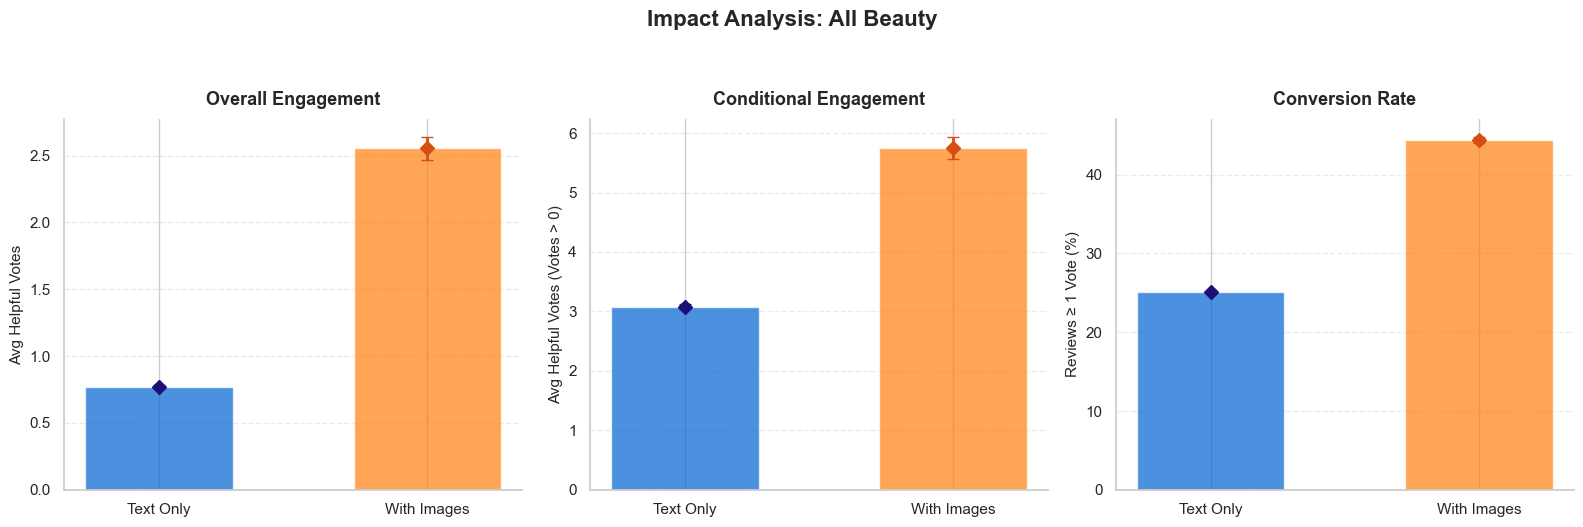

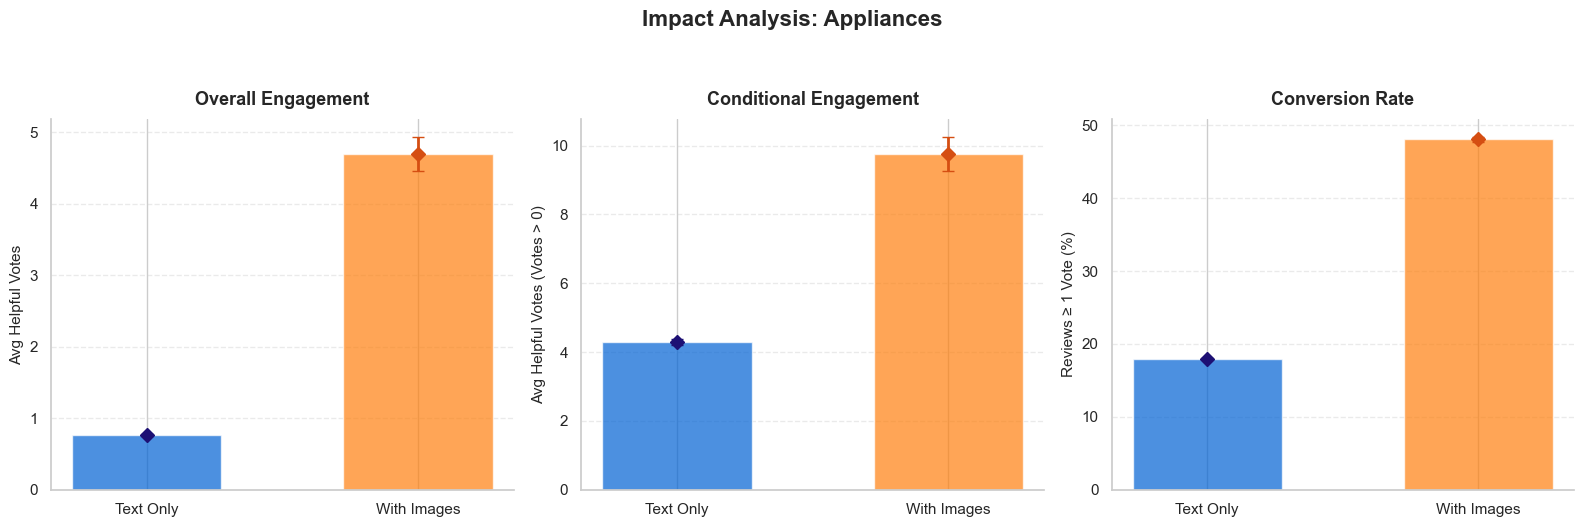

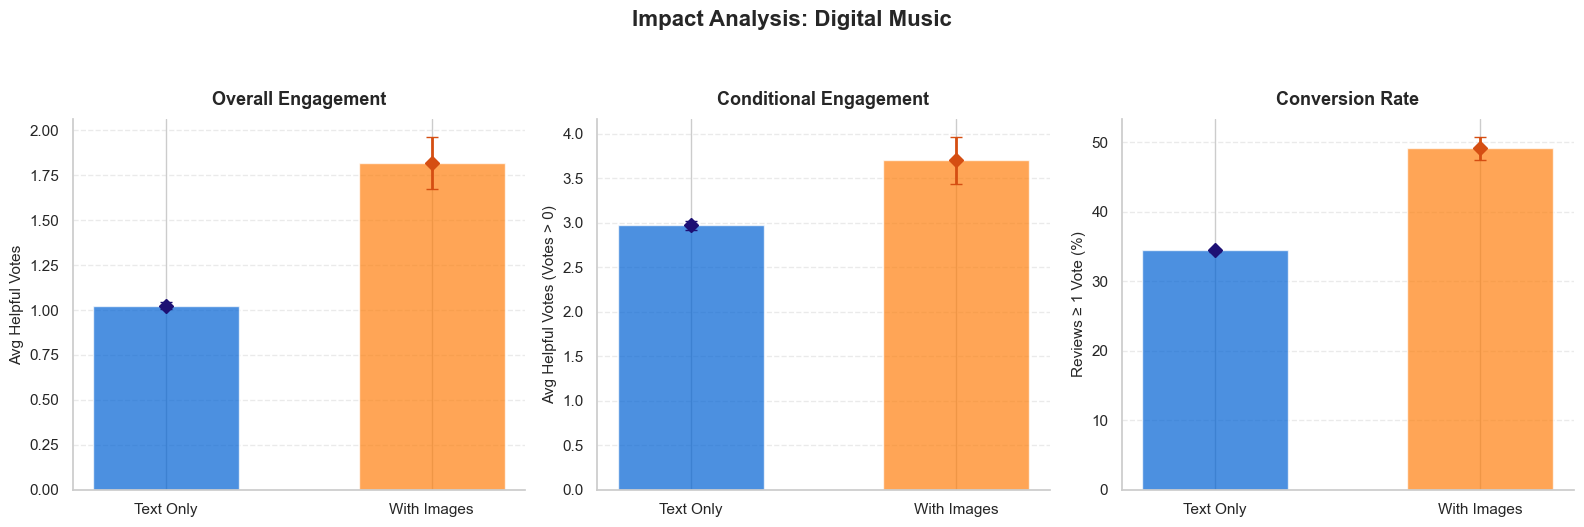

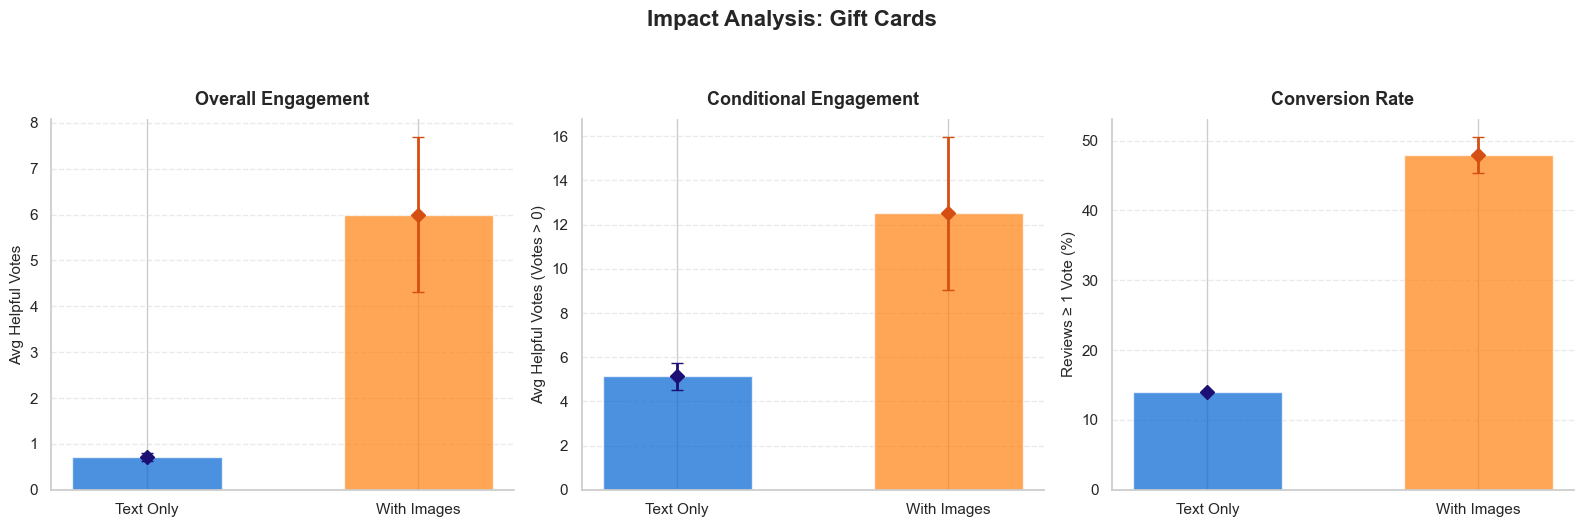

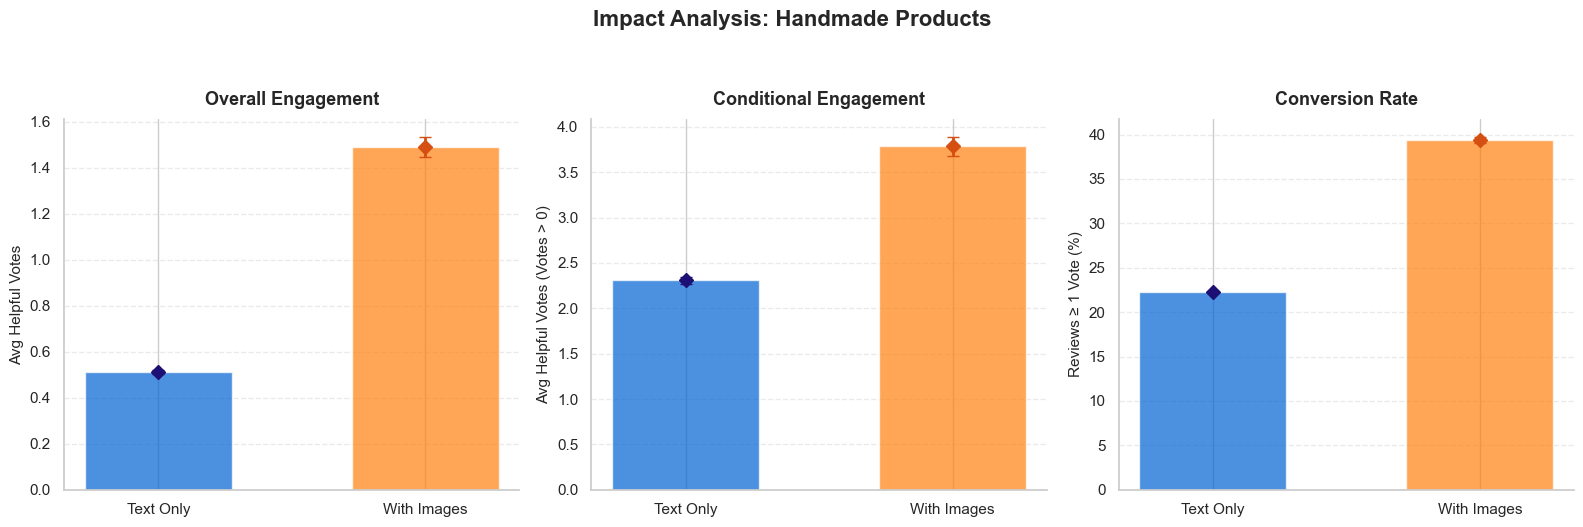

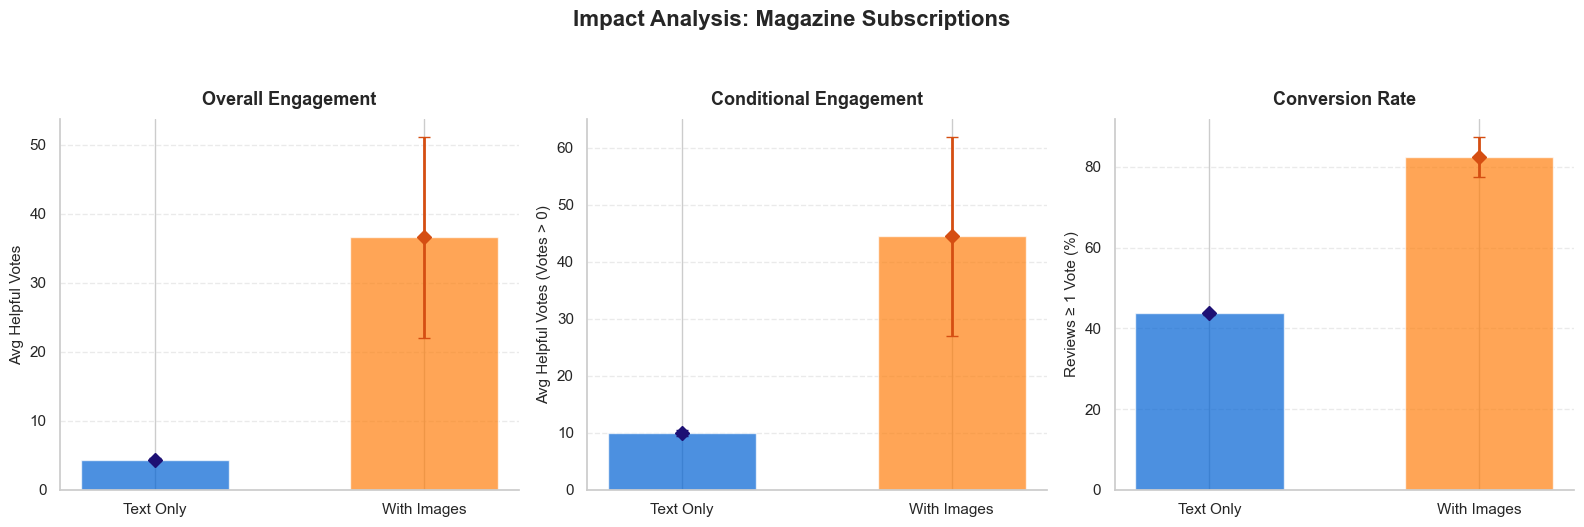

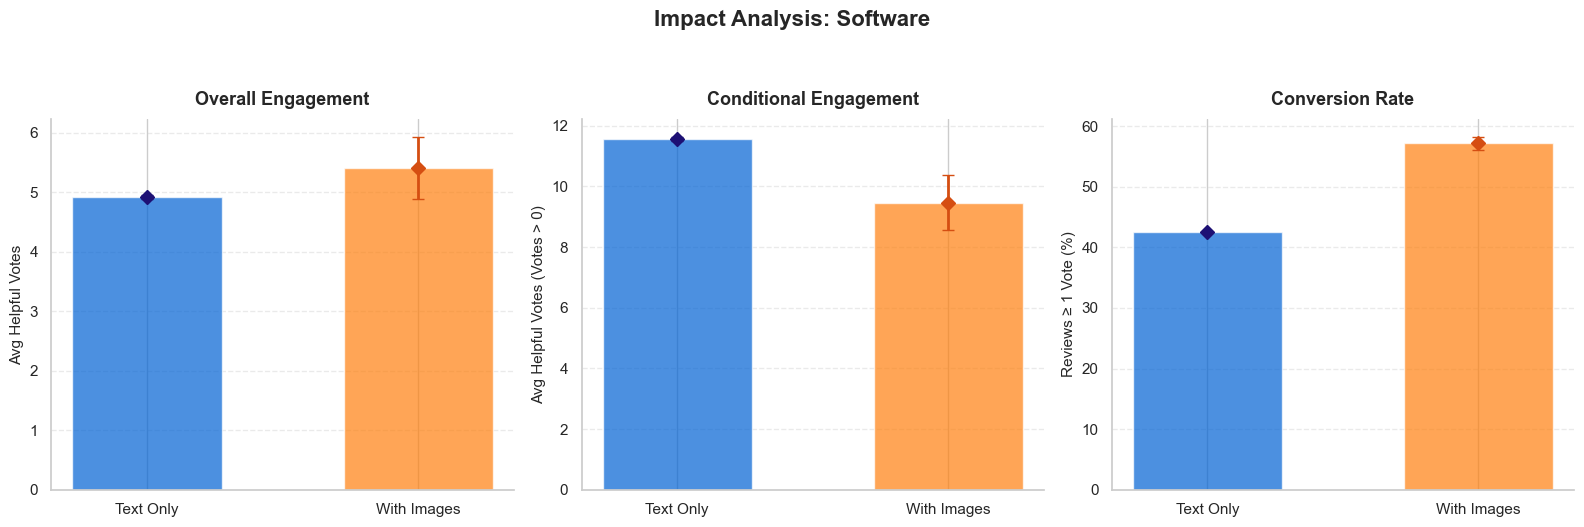

In [16]:
plot_df = pd.read_csv(os.path.join(CSV_PATH, "plot_img_help.csv"))

sns.set_theme(style="whitegrid")

# Define Original and Darker versions of the colors
blue, dark_blue = "#0061d4", "#1d1074"
orange, dark_orange = "#ff7f0e", "#d54e12"

colors = [blue, orange]
dark_colors = [dark_blue, dark_orange]
labels = ["Text Only", "With Images"]

for cat in plot_df["Category"].unique():
    df = plot_df[plot_df["Category"] == cat].sort_values("has_images")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    x = np.arange(2)
    width = 0.55

    metrics = [
        ("mean_helpful", "ci95_helpful", "Overall Engagement", "Avg Helpful Votes"),
        (
            "cond_mean",
            "cond_ci95",
            "Conditional Engagement",
            "Avg Helpful Votes (Votes > 0)",
        ),
        ("conv_rate", "conv_ci95", "Conversion Rate", "Reviews ≥ 1 Vote (%)"),
    ]

    for i, (col, err_col, title, ylabel) in enumerate(metrics):
        ax = axes[i]

        ax.bar(x, df[col], width=width, color=colors, alpha=0.7, zorder=2)

        # loop to apply different diamond colors
        for j in range(len(x)):
            ax.errorbar(
                x[j],
                df[col].iloc[j],
                yerr=df[err_col].iloc[j],
                fmt="D",  # Diamond marker
                mfc=dark_colors[j],
                mec=dark_colors[j],
                ms=7,
                ecolor=dark_colors[j],
                elinewidth=2,
                capsize=4,
                zorder=3,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=11)
        ax.set_title(title, fontsize=13, weight="bold", pad=10)
        ax.set_ylabel(ylabel, fontsize=11)

        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(
        f"Impact Analysis: {cat.replace('_', ' ')}",
        fontsize=16,
        weight="bold",
        y=1.05,
    )

    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_PATH, f"img_help_{cat}.png"), dpi=300, bbox_inches="tight"
    )
    plt.show()
    plt.close()

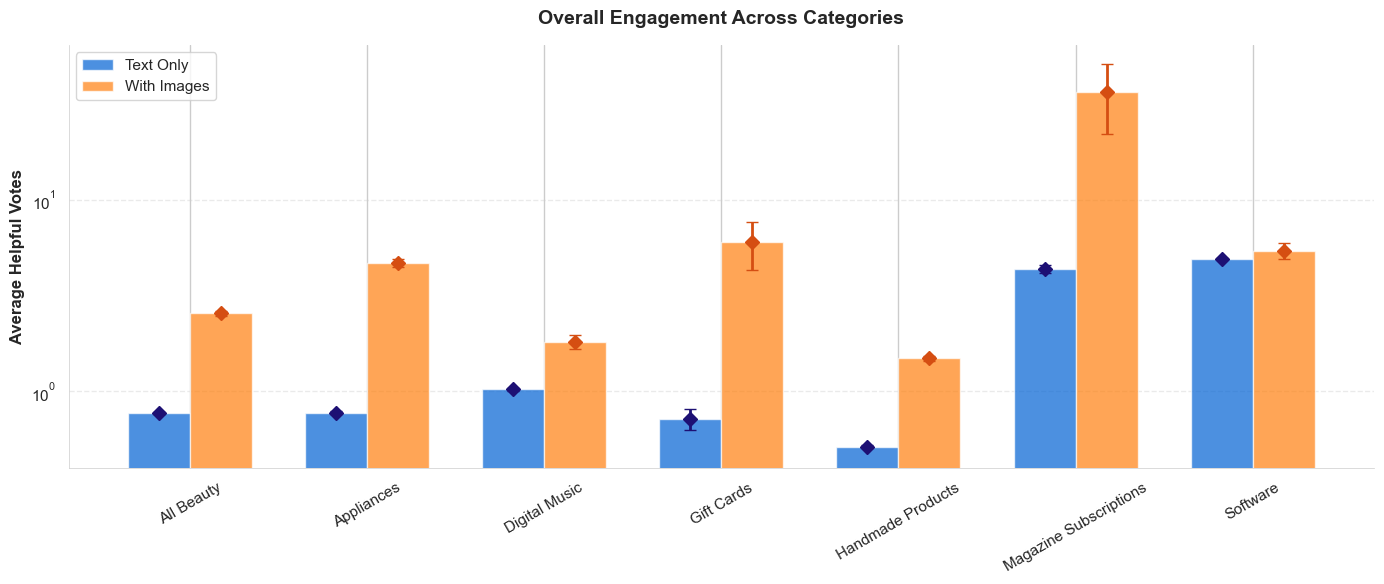

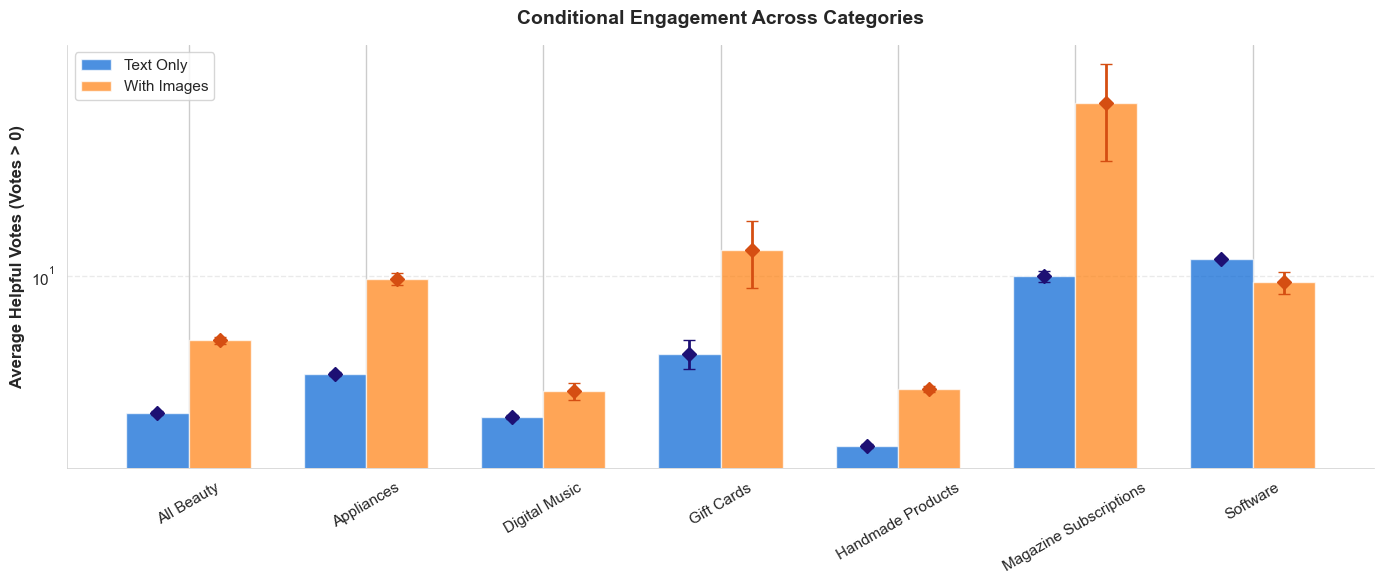

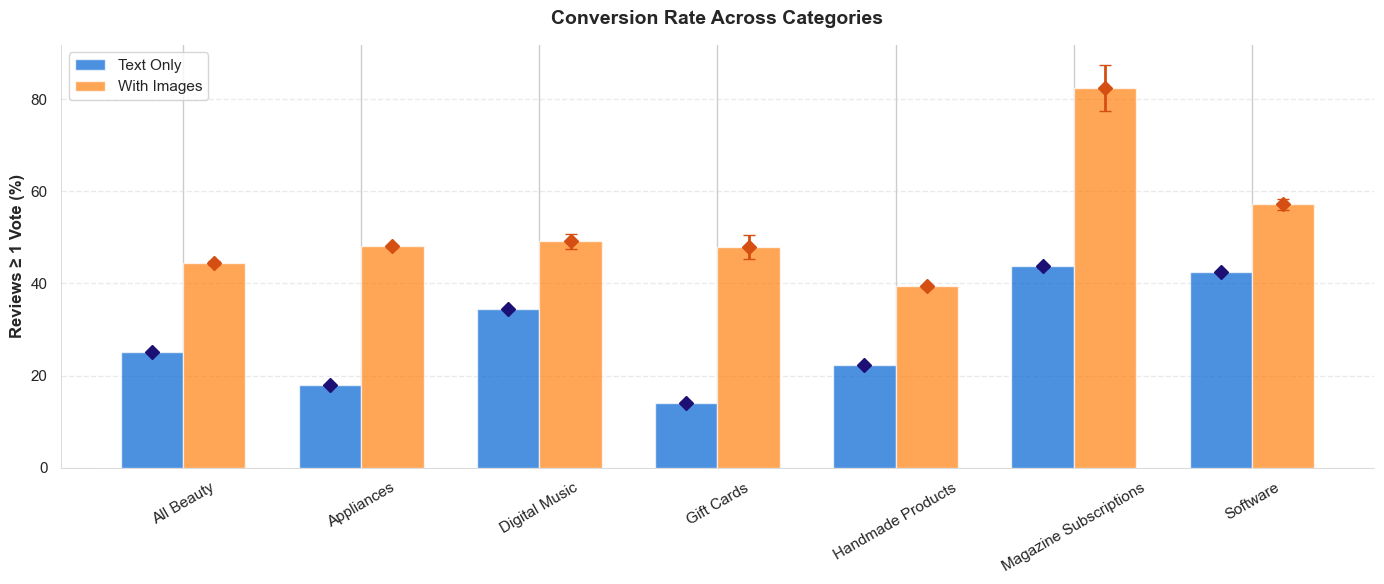

In [19]:
plot_df = pd.read_csv(os.path.join(CSV_PATH, "plot_img_help.csv"))

sns.set_theme(style="whitegrid")

# --- Finalized Theme Colors ---
blue, dark_blue = "#0061d4", "#1d1074"
orange, dark_orange = "#ff7f0e", "#d54e12"

categories = plot_df["Category"].unique()
n = len(categories)
x = np.arange(n)
width = 0.35


def build_plot(
    metric, error_metric, ylabel, title, filename, log_scale=False, show_corr=False
):
    fig, ax = plt.subplots(figsize=(14, 6))

    text_vals, img_vals = [], []
    text_err, img_err = [], []

    for cat in categories:
        df_cat = plot_df[plot_df["Category"] == cat].sort_values("has_images")
        text_vals.append(df_cat[df_cat["has_images"] == False][metric].values[0])
        img_vals.append(df_cat[df_cat["has_images"] == True][metric].values[0])
        text_err.append(df_cat[df_cat["has_images"] == False][error_metric].values[0])
        img_err.append(df_cat[df_cat["has_images"] == True][error_metric].values[0])

    ax.bar(
        x - width / 2,
        text_vals,
        width,
        label="Text Only",
        color=blue,
        alpha=0.7,
        zorder=2,
    )
    ax.errorbar(
        x - width / 2,
        text_vals,
        yerr=text_err,
        fmt="D",
        mfc=dark_blue,
        mec=dark_blue,
        ms=7,
        ecolor=dark_blue,
        elinewidth=2,
        capsize=4,
        linestyle="none",
        zorder=3,
    )

    ax.bar(
        x + width / 2,
        img_vals,
        width,
        label="With Images",
        color=orange,
        alpha=0.7,
        zorder=2,
    )
    ax.errorbar(
        x + width / 2,
        img_vals,
        yerr=img_err,
        fmt="D",
        mfc=dark_orange,
        mec=dark_orange,
        ms=7,
        ecolor=dark_orange,
        elinewidth=2,
        capsize=4,
        linestyle="none",
        zorder=3,
    )

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(
        [c.replace("_", " ") for c in categories], rotation=30, fontsize=11
    )
    ax.set_ylabel(ylabel, fontsize=12, weight="bold")

    if show_corr:
        corr = plot_df["Correlation"].mean()  # Using mean or specific logic
        p_val = plot_df["P_Value"].mean()
        ax.set_title(
            f"{title}\nPoint-biserial Corr: {corr:.2f}, p={p_val}",
            fontsize=14,
            weight="bold",
            pad=15,
        )
    else:
        ax.set_title(title, fontsize=14, weight="bold", pad=15)

    ax.legend(frameon=True, loc="upper left")
    if log_scale:
        ax.set_yscale("log")

    # Final styling to match theme
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)

    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_PATH, f"{filename}.png"), dpi=600, bbox_inches="tight"
    )
    plt.show()


# -------------------------- Overall Engagement
build_plot(
    metric="mean_helpful",
    error_metric="ci95_helpful",
    ylabel="Average Helpful Votes",
    title="Overall Engagement Across Categories",
    log_scale=True,
    filename="consolidated_overall_engagement",
)

# -------------------------- Conditional Engagement (Votes > 0)
build_plot(
    metric="cond_mean",
    error_metric="cond_ci95",
    ylabel="Average Helpful Votes (Votes > 0)",
    title="Conditional Engagement Across Categories",
    log_scale=True,
    filename="consolidated_conditional_engagement",
)

# -------------------------- Conversion Rate
build_plot(
    metric="conv_rate",
    error_metric="conv_ci95",
    ylabel="Reviews ≥ 1 Vote (%)",
    title="Conversion Rate Across Categories",
    log_scale=False,
    filename="consolidated_onversion_rate",
)

#### Temporal Analysis

Completed filter + merge of metadata.


g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


...

g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


g:\AmazonReviewsDataAnalysis\scripts\reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


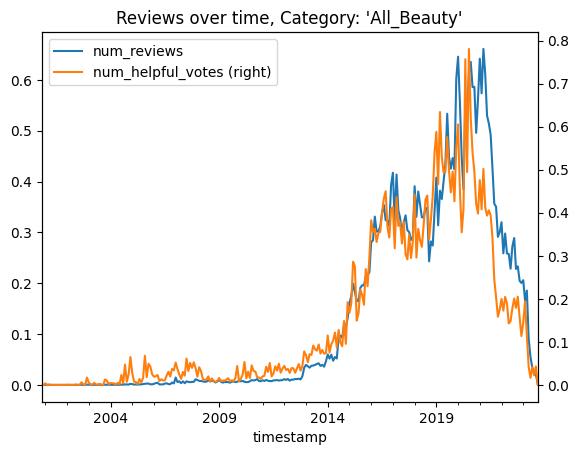

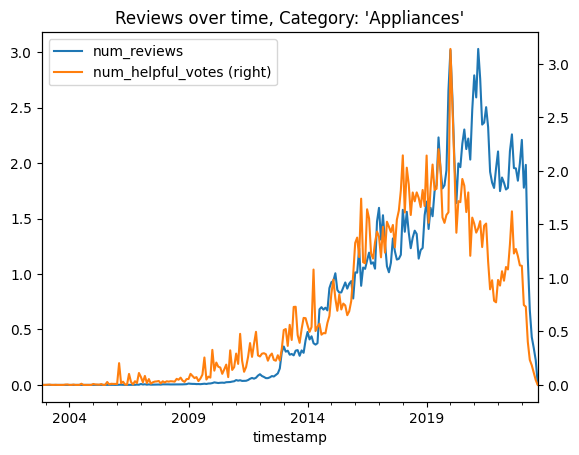

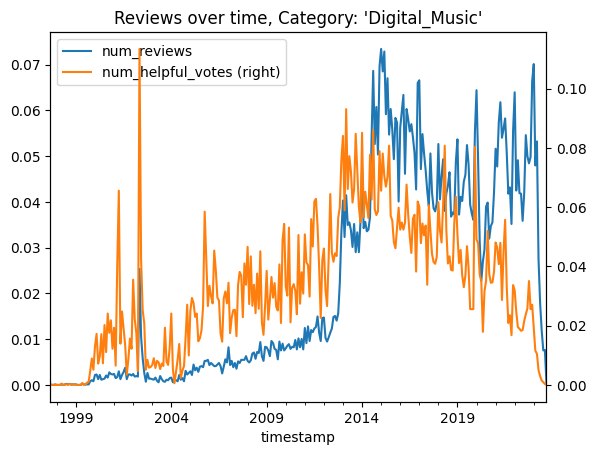

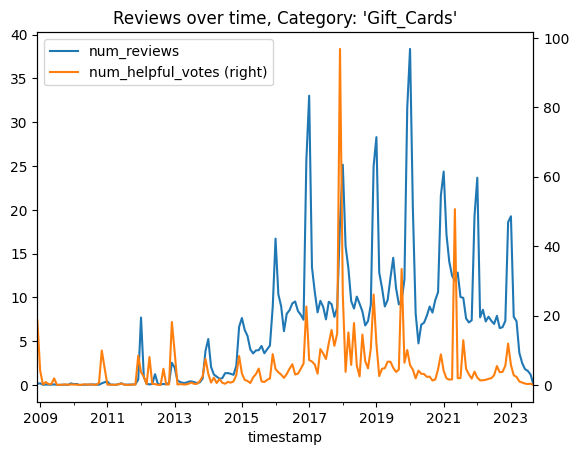

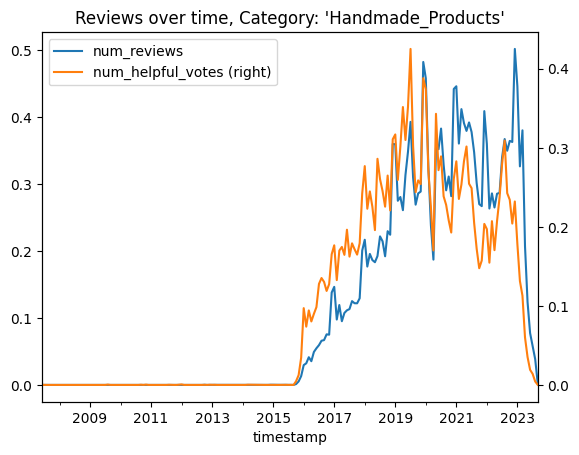

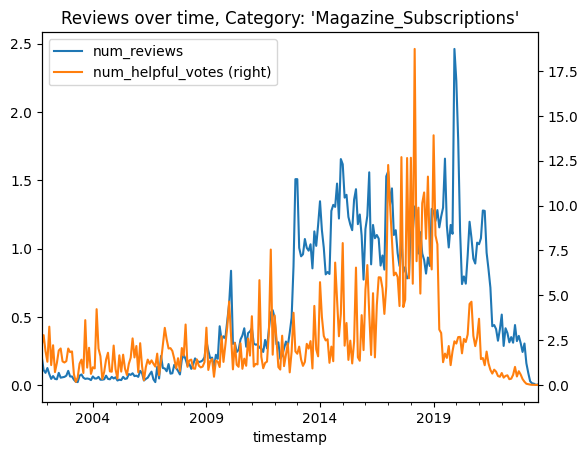

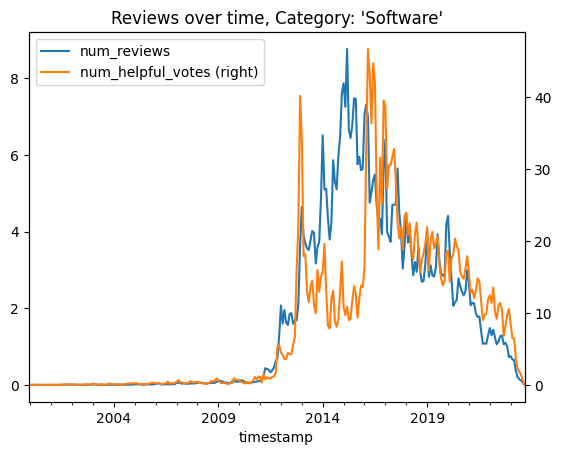

In [3]:
plot_data = dict()
for category in categories:
    time, num_reviews, helpful_votes = plot_reviews_over_time(category)
    plot_data[category] = [time, num_reviews, helpful_votes]

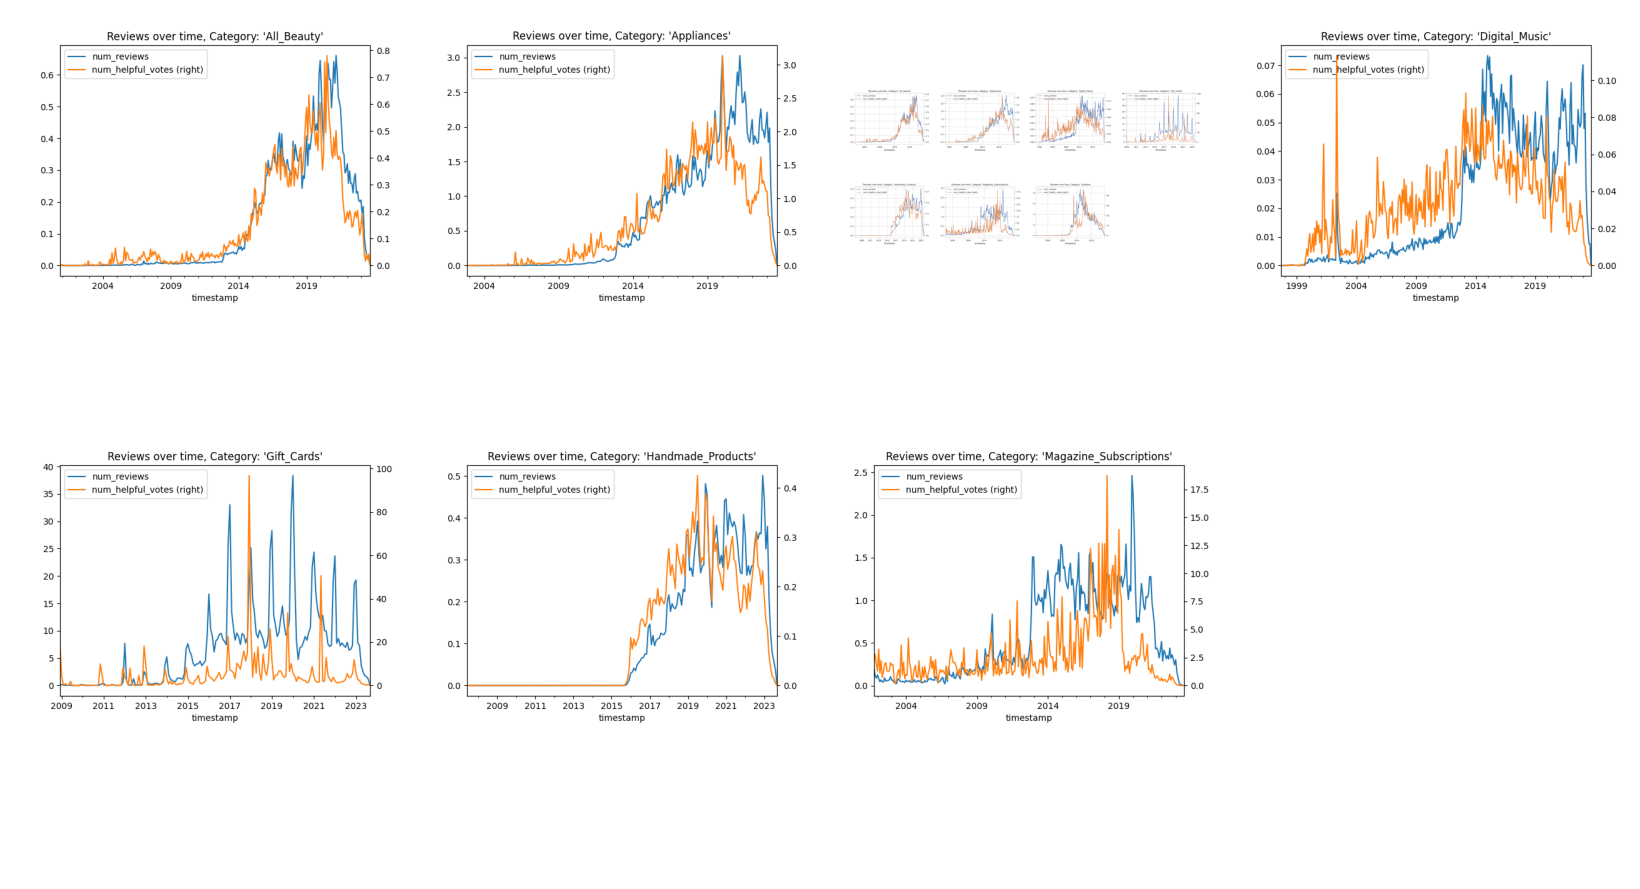

In [4]:
contents = os.listdir("plots/")

# 2. Filter for files that start with "temporal_"
temporal_files = [f for f in contents if f.startswith("temporal_")]
image_files = [os.path.join("plots/", f) for f in temporal_files]

num_images = min(len(image_files), 7)

fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for i in range(len(axes)):
    if i < num_images:
        img = mpimg.imread(image_files[i])
        axes[i].imshow(img)
        axes[i].axis("off")
    else:
        # Hide extra subplots if there are fewer than 6 images
        axes[i].axis("off")

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3
)

plt.savefig("plots/temporal_categories_reviews.png")
plt.show()

### Observations:
- It seems like a spike in reviews is almost always preceded by a spike in helpful votes
- Most of the categories seem to have a similar trend shape, with slow growth in the beginning followed by a sharp uptick in "popularity"

### Next Step:
- Perhaps, we can see if a lagged helpful votes variable actually is predictive of number of reviews or not

Generating correlation plot...
Correlation peaks at lag = 7
Computing OLS...
                            OLS Regression Results                            
Dep. Variable:                reviews   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1440.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          4.60e-143
Time:                        23:18:23   Log-Likelihood:                 405.24
No. Observations:                 268   AIC:                            -804.5
Df Residuals:                     265   BIC:                            -793.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

ValueError: maxlag must be a positive integer

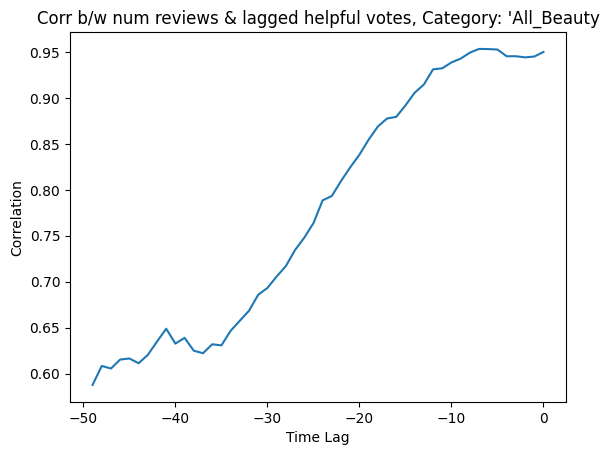

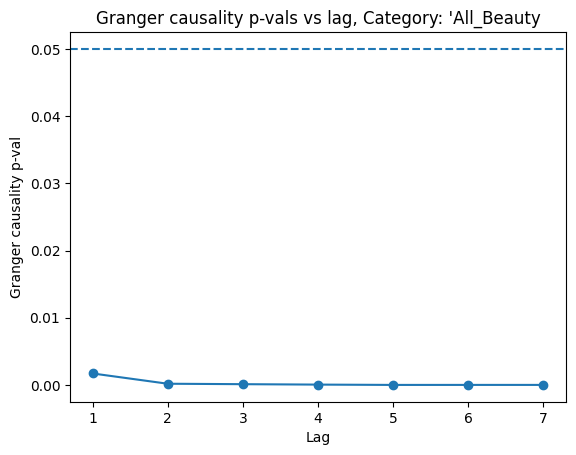

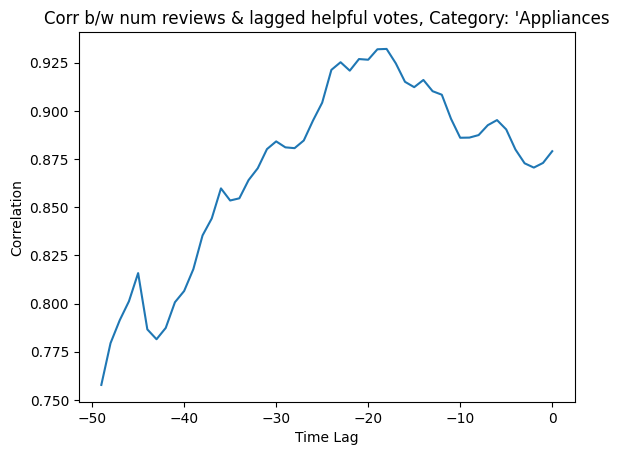

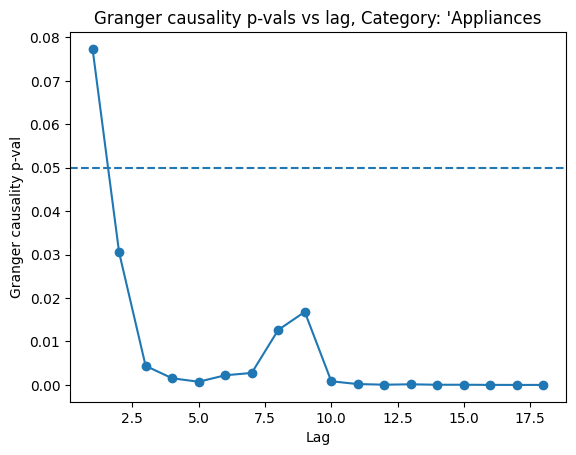

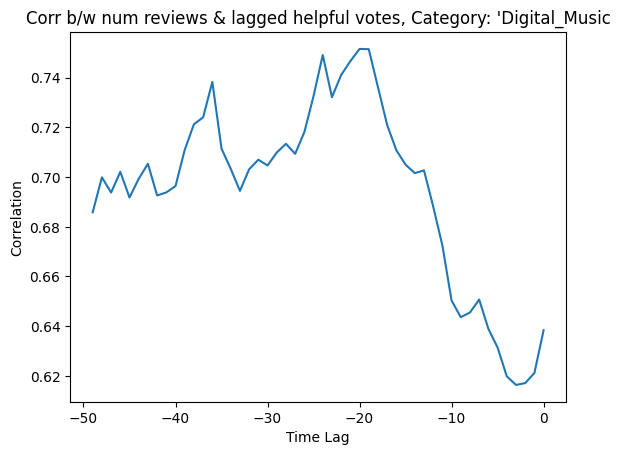

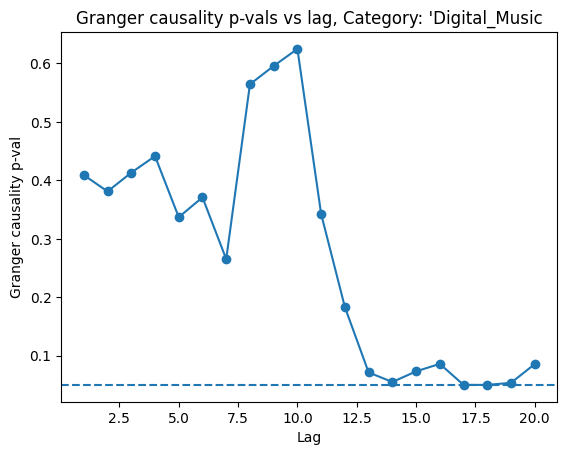

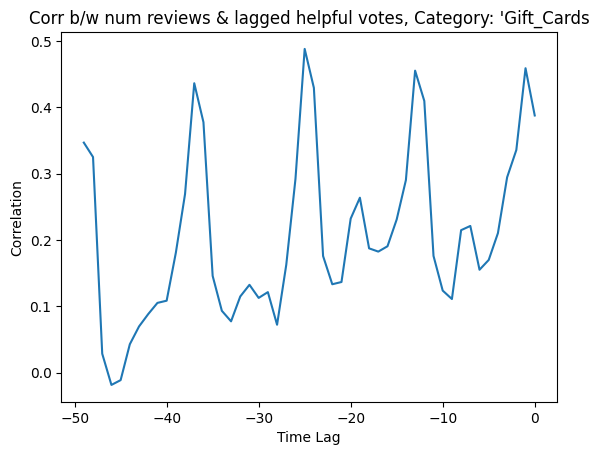

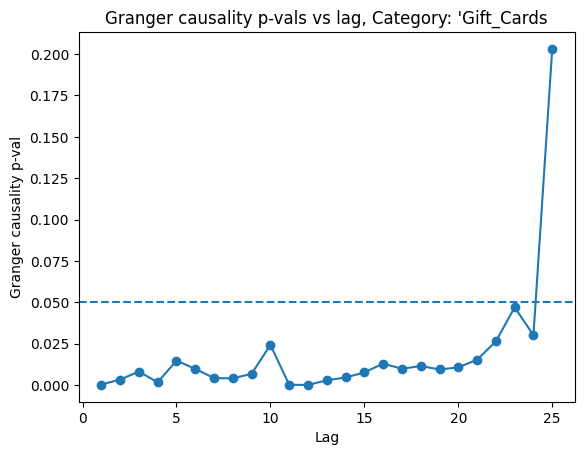

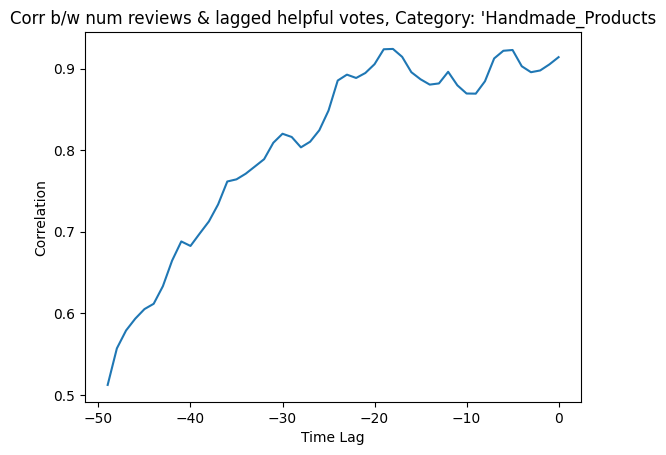

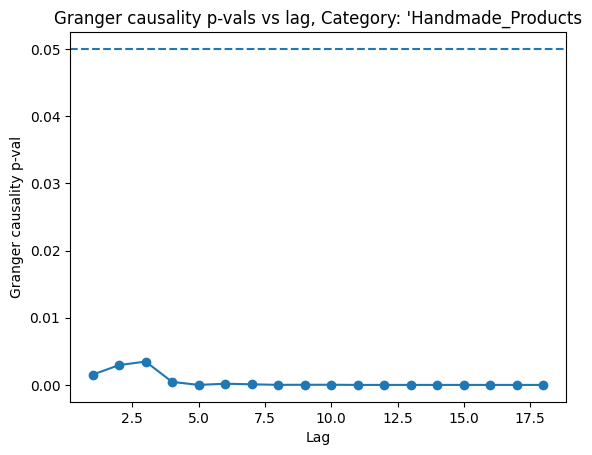

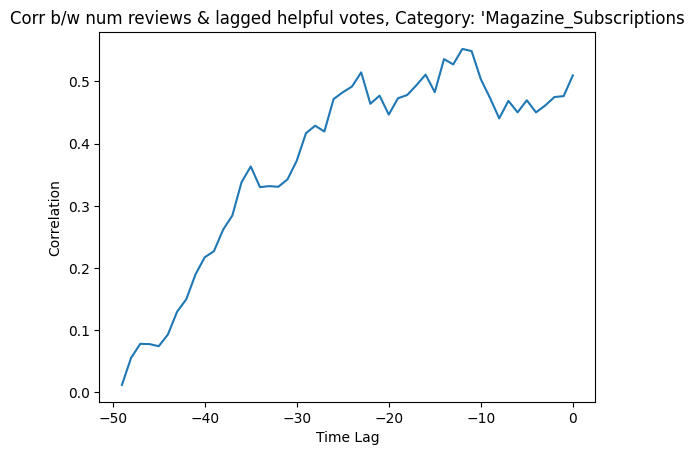

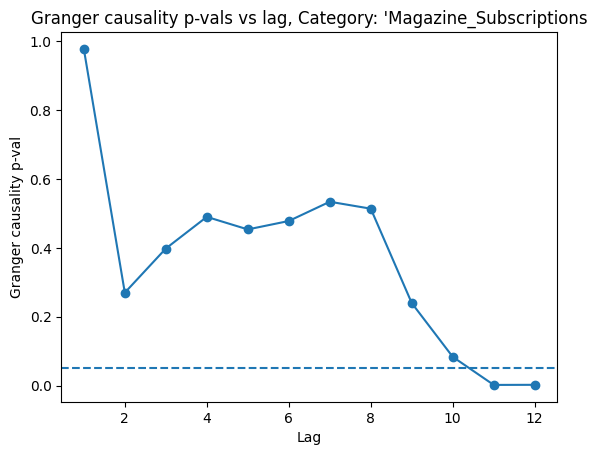

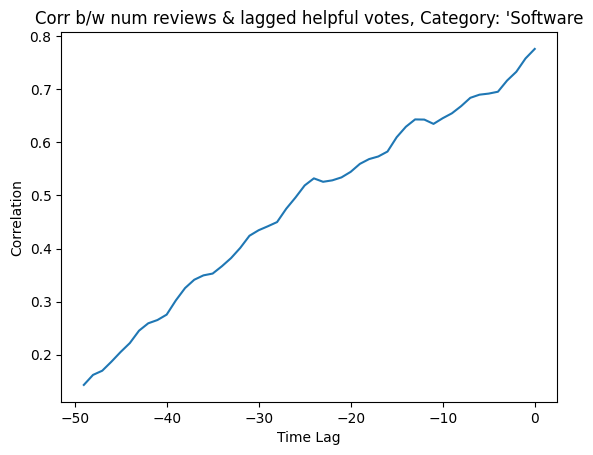

In [5]:
for category in categories:
    time, num_reviews, helpful_votes = plot_data[category]
    run_tests(time, num_reviews, helpful_votes, category=category)

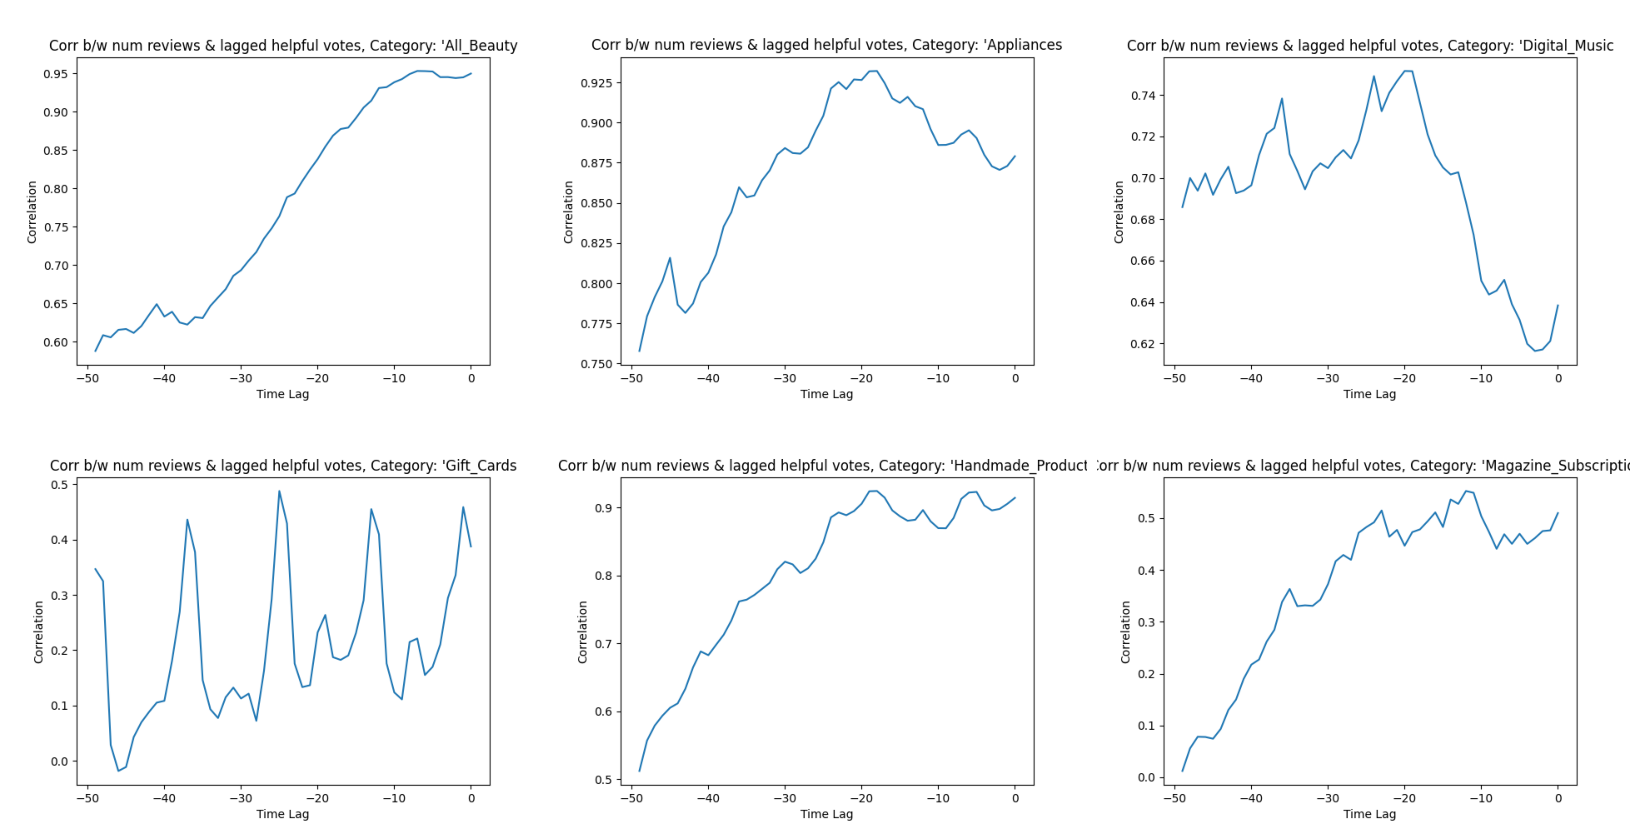

In [6]:
# Uncomment cell to generate a single figure with all the correlation plots

contents = os.listdir("plots/")
contents = list(filter(lambda x: x[:4] == "corr", contents))
image_files = list(map(lambda x: "plots/" + x, contents))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3
)

plt.savefig(os.path.join(PLOTS_PATH, "categories_correlation.png"), dpi=600)
plt.show()

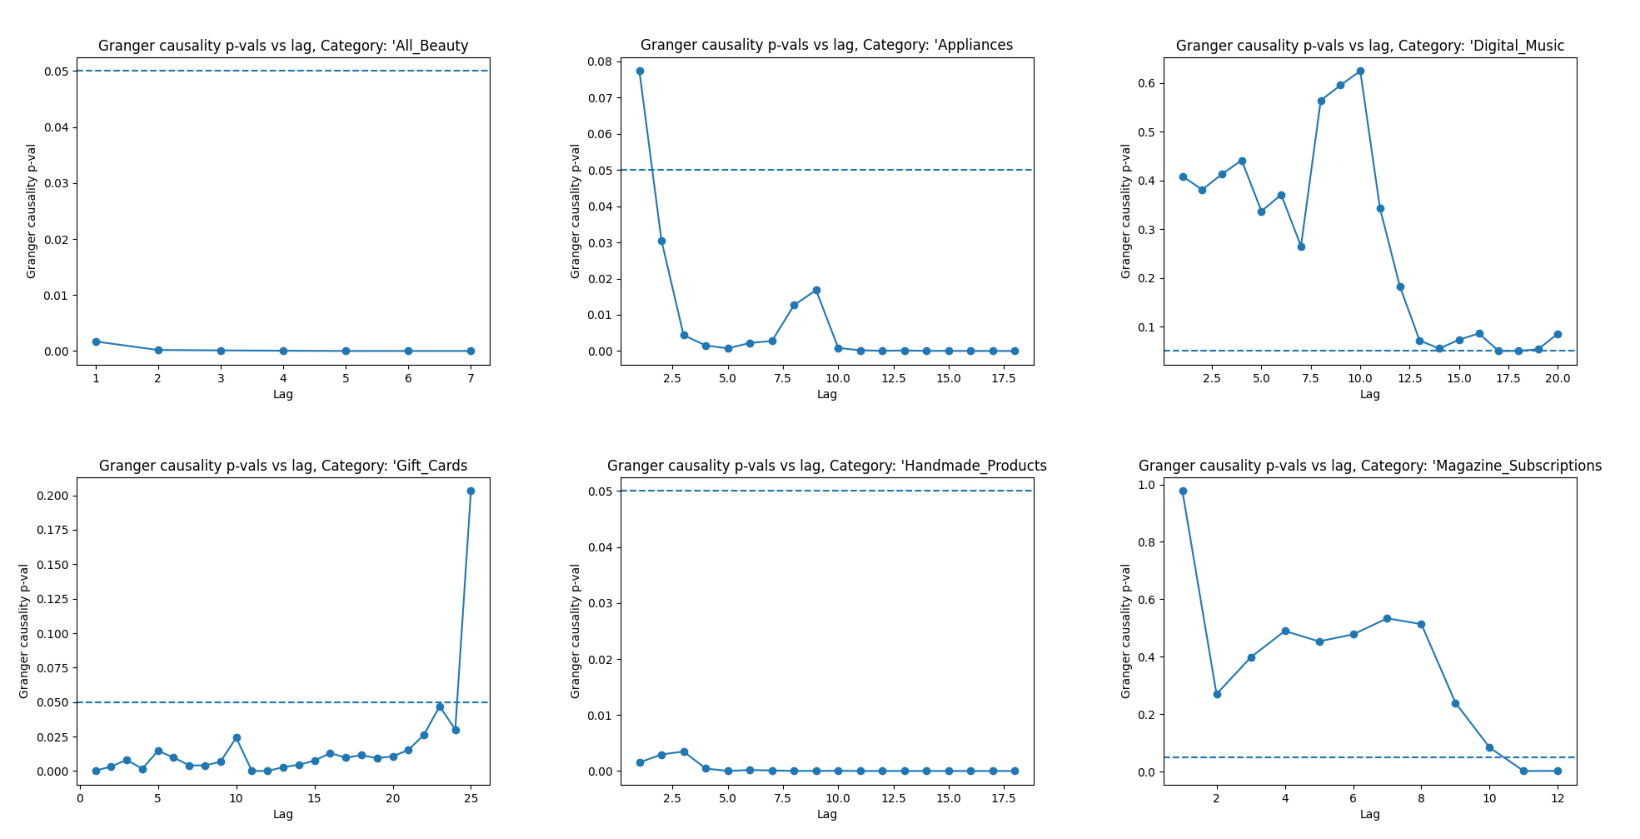

In [7]:
# Uncomment cell to generate a single figure with all the granger plots

contents = os.listdir("plots/")
contents = list(filter(lambda x: x[:7] == "granger", contents))
image_files = list(map(lambda x: "plots/" + x, contents))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3
)

plt.savefig(os.path.join(PLOTS_PATH, "categories_granger.png"), dpi=600)
plt.show()

### Observations:
- Correlation seems to increase as we use data from months that are more recent, but the increase is not linear
- For some categories, the highest correlated month is actually a few months back (not the most recent month)
- In the OLS analysis, we see that helpful votes for the highest correlated month is positively impacting num reviews with a p-value well below 0.01
- The Durbin-Watson metric is between 0.7 and 1.0 for all the OLS tests, which indicates moderate amounts of autocorrelation
- The Granger Causality test tells us that adding more months does not necessarily give us high-confidence relationships. A general trend though is a decrease in p-value to below the threshold of alpha = 0.05 as we add more months.

#### Helpfulness Analysis

In [30]:
results = []

for category in categories:
    row = analyze_category(category)
    results.append(row)

summary = pd.DataFrame(results)

output_path = os.path.join(CSV_PATH, "helpfulness_summary.csv")
os.makedirs(CSV_PATH, exist_ok=True)
summary.to_csv(output_path, index=False)

print(f"Summary saved to: {output_path}")
display(summary.head())


Processing: All_Beauty
Loading reviews: G:\AmazonReviewsDataAnalysis/review_categories\All_Beauty.jsonl
Loading metadata: G:\AmazonReviewsDataAnalysis/meta_categories\meta_All_Beauty.jsonl
Merging on parent_asin...
  Rows loaded: 701528
  Extremity bias — 1-star: 0.300,2-star: 0.267,3-star: 0.261,4-star: 0.272 5-star: 0.259
  Length effect — 400+: 0.717, 50-99 ref: 0.431
  Verified effect — True: 0.266, False: 0.283, Delta: -0.017
  Price effect — High bucket: 0.3494804078919638

Processing: Appliances
Loading reviews: G:\AmazonReviewsDataAnalysis/review_categories\Appliances.jsonl
Loading metadata: G:\AmazonReviewsDataAnalysis/meta_categories\meta_Appliances.jsonl
Merging on parent_asin...
  Rows loaded: 2128605
  Extremity bias — 1-star: 0.369,2-star: 0.295,3-star: 0.280,4-star: 0.227 5-star: 0.145
  Length effect — 400+: 0.884, 50-99 ref: 0.402
  Verified effect — True: 0.184, False: 0.369, Delta: -0.184
  Price effect — High bucket: 0.23447240236886316

Processing: Digital_Music
L

,Category,One_Star,Two_Star,Three_Star,Four_Star,Five_Star,0to2,3to19,20to49,50to99,100to199,200to399,400plus,Verified,Unverified,Low_Price,Mid_Price,High_Price
0,All_Beauty,0.300,0.267,0.261,0.272,0.259,0.121,0.181,0.296,0.431,0.552,0.639,0.717,0.266,0.283,0.258,0.298,0.349
1,Appliances,0.369,0.295,0.280,0.227,0.145,0.051,0.094,0.218,0.402,0.605,0.769,0.884,0.184,0.369,0.138,0.153,0.234
2,Digital_Music,0.391,0.387,0.376,0.407,0.335,0.131,0.195,0.364,0.513,0.624,0.705,0.741,0.295,0.498,0.324,0.346,0.366
3,Gift_Cards,0.511,0.360,0.299,0.230,0.096,0.057,0.094,0.251,0.488,0.667,0.801,0.857,0.140,0.188,0.109,0.281,0.225
4,Handmade_Products,0.346,0.319,0.307,0.270,0.227,0.138,0.184,0.287,0.417,0.520,0.568,0.700,0.245,0.236,0.209,0.243,0.309


#### Test: Helpfulness based on Verified Purchase

<Figure size 1200x600 with 0 Axes>

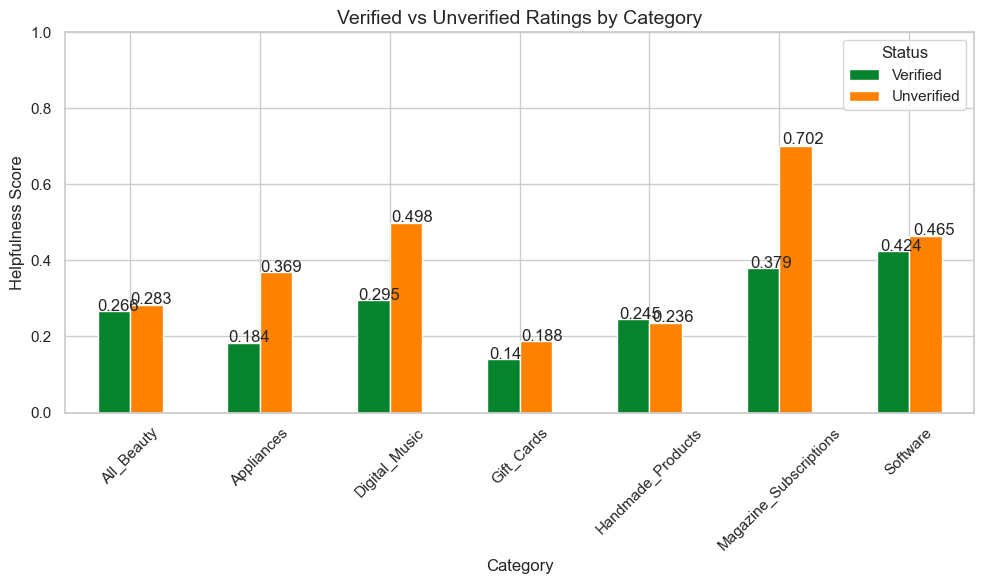

In [31]:
df = pd.read_csv("./csv/helpfulness_summary.csv")

result_dict = df.set_index('Category')[['Verified', 'Unverified']].to_dict(orient='index')
plt.figure(figsize=(12, 6))
ax = df.plot(x='Category', y=['Verified', 'Unverified'], kind='bar', figsize=(10, 6),color = ['#05832d', "#ff8100"])

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
ax.set_ylim(0, 1)
plt.title('Verified vs Unverified Ratings by Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Helpfulness Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()

# Save and Show
plt.savefig(os.path.join(PLOTS_PATH, "verified_vs_unverified.png"), dpi=600)
plt.show()

#### Test: Helpfulness based on Review Rating

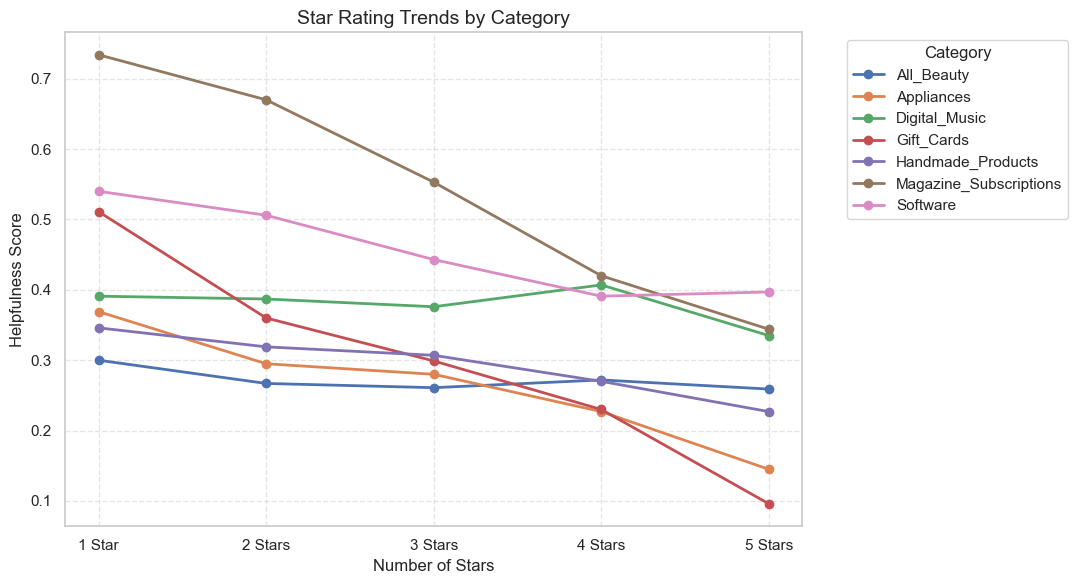

In [32]:
star_cols = ['One_Star', 'Two_Star', 'Three_Star', 'Four_Star', 'Five_Star']
star_labels = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

plt.figure(figsize=(11, 6))

for index, row in df.iterrows():
    plt.plot(star_labels, row[star_cols], marker='o', label=row['Category'], linewidth=2)
ax.set_ylim(0, 1)

plt.title('Star Rating Trends by Category', fontsize=14)
plt.xlabel('Number of Stars', fontsize=12)
plt.ylabel('Helpfulness Score', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_PATH, "regular_line_stars.png"), dpi=600)
plt.show()

#### Test: Helpfulness Based on length of review

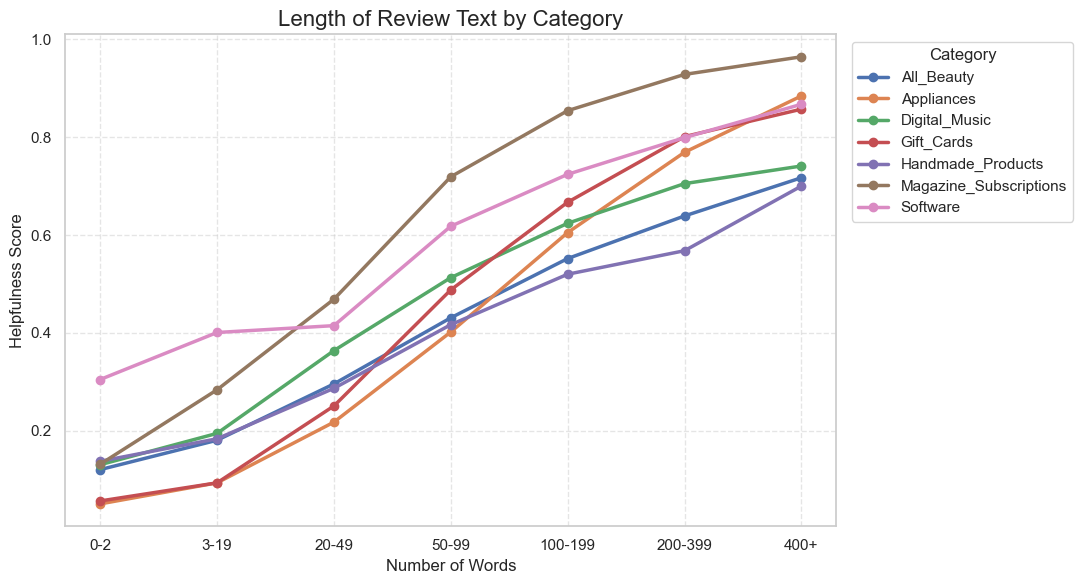

In [33]:
star_cols = ['0to2', '3to19', '20to49', '50to99', '100to199', '200to399', '400plus']
star_labels = ['0-2', '3-19', '20-49', '50-99', '100-199', '200-399', '400+']

plt.figure(figsize=(11, 6))

for index, row in df.iterrows():
    plt.plot(star_labels, row[star_cols], marker='o', label=row['Category'], linewidth=2.5)

plt.title('Length of Review Text by Category', fontsize=16)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Helpfulness Score', fontsize=12)


plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_PATH, "wide_line_chart.png"), dpi=600)
plt.show()